<h3> Installing Important Libraries </h3>

In [78]:
!pip install brainflow
!pip install matplotlib
!pip install numpy
!pip install scipy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3> Library Imports </h3>

In [14]:
from brainflow.board_shim import BrainFlowInputParams, BoardShim
from brainflow.data_filter import DataFilter, FilterTypes
import time
import matplotlib.pyplot as plt
import numpy as np

<h3> Set Up Device Parameters </h3>

In [3]:
params = BrainFlowInputParams()
params.serial_port = 'COM3'
board_id = 0  # 0 is id for OpenBCI Cyton

<h3> Create Brainflow Board Object </h3>

In [4]:
try:
    board = BoardShim(board_id, params)
    board.prepare_session()
    print("Board initialized successfully.")
except Exception as e:
    print(f"Error initializing board: {e}")
    exit(1)
finally:
    board.release_session()

Board initialized successfully.


<h3> Read Data From Board </h3>

In [98]:
print("Starting data acquisition...")
try:
    board.prepare_session()
    board.start_stream()
    time.sleep(15)  # Collect data for 5 seconds
    data = board.get_board_data()
    print("Data collected successfully.")
    board.stop_stream()
except Exception as e:   
    print(f"Error during data acquisition: {e}")
finally:
    board.release_session()


Starting data acquisition...
Data collected successfully.


In [99]:
eeg_channels = BoardShim.get_eeg_channels(board.board_id)
data = data[eeg_channels]
print(data.shape)

(8, 3688)


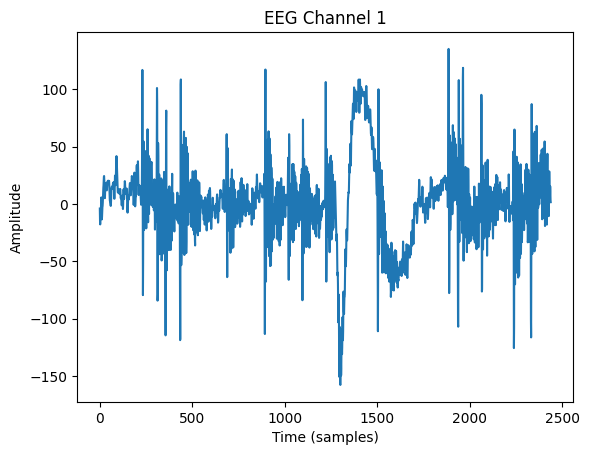

In [100]:
DataFilter.perform_bandpass(data[0], 250, 0.5, 40, 4, FilterTypes.BUTTERWORTH.value, 0)
DataFilter.perform_bandstop(data[0], 250, 48, 52, 4, FilterTypes.BUTTERWORTH.value, 0)
data = data[:, 1250 :]
plt.plot(np.arange(data.shape[1]), data[0])
plt.title("EEG Channel 1")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()